<a href="https://colab.research.google.com/github/arshiyaarshu1999-cyber/INSE_6180/blob/main/Mobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Android Malware Detection.csv")
df.head()



,Unnamed: 0,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_NETWORK_STATE,ACCESS_SURFACE_FLINGER,...,WRITE_GSERVICES,WRITE_MEDIA_STORAGE,WRITE_PROFILE,WRITE_SECURE_SETTINGS,WRITE_SETTINGS,WRITE_SMS,WRITE_SOCIAL_STREAM,WRITE_SYNC_SETTINGS,WRITE_USER_DICTIONARY,Label
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop rows where 'Label' column has NaN values
df_cleaned = df.dropna(subset=['Label'])

X = df_cleaned.drop("Label", axis=1)   # Target variable is 'Label'
y = df_cleaned["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Results")
print(classification_report(y_test, rf_pred))


Random Forest Results
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       215
         1.0       0.99      0.99      0.99       758

    accuracy                           0.99       973
   macro avg       0.99      0.99      0.99       973
weighted avg       0.99      0.99      0.99       973



In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
print("SVM Results")
print(classification_report(y_test, svm_pred))


SVM Results
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95       215
         1.0       0.99      0.98      0.99       758

    accuracy                           0.98       973
   macro avg       0.96      0.97      0.97       973
weighted avg       0.98      0.98      0.98       973



In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)
print("Naive Bayes Results")
print(classification_report(y_test, nb_pred))


Naive Bayes Results
              precision    recall  f1-score   support

         0.0       0.23      0.99      0.38       215
         1.0       0.96      0.07      0.13       758

    accuracy                           0.27       973
   macro avg       0.60      0.53      0.25       973
weighted avg       0.80      0.27      0.18       973



In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca, y_train)

rf_pca_pred = rf_pca.predict(X_test_pca)
print("Proposed PCA-RF Results")
print(classification_report(y_test, rf_pca_pred))


Proposed PCA-RF Results
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       215
         1.0       0.99      0.99      0.99       758

    accuracy                           0.99       973
   macro avg       0.98      0.98      0.98       973
weighted avg       0.99      0.99      0.99       973



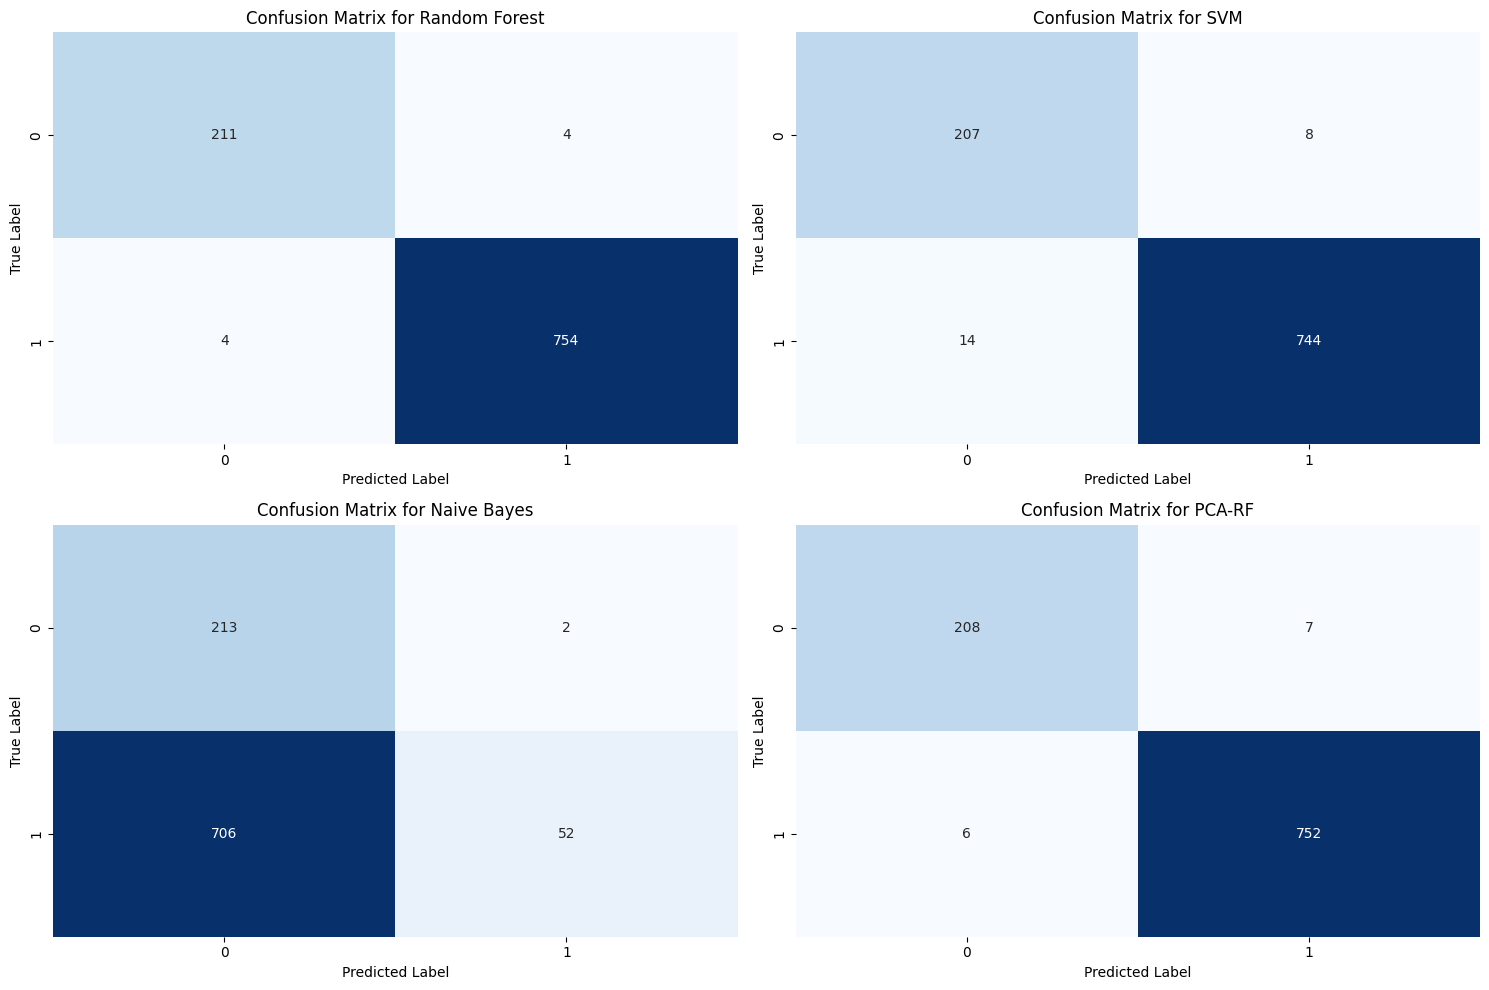

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Random Forest": rf_pred,
    "SVM": svm_pred,
    "Naive Bayes": nb_pred,
    "PCA-RF": rf_pca_pred # Adding the PCA-RF model predictions
}

plt.figure(figsize=(15, 10)) # Adjust figure size for better readability of multiple plots

for i, (name, pred) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i) # Creating a 2x2 grid for 4 models
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False) # Plotting the confusion matrix
    plt.title(f'Confusion Matrix for {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


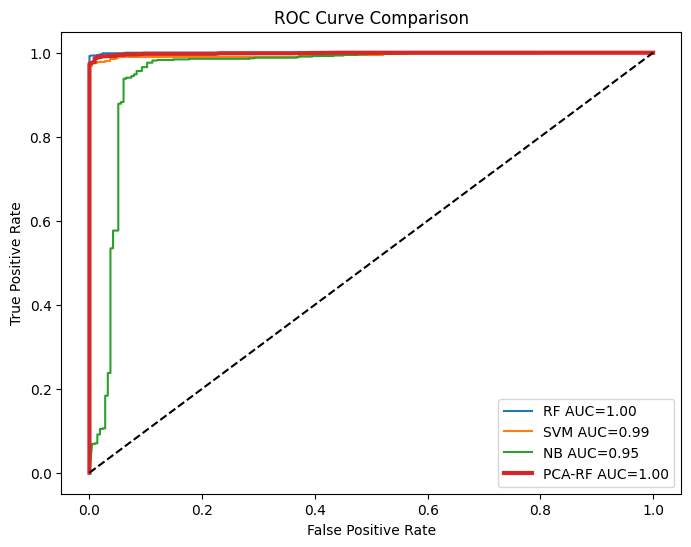

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm.predict_proba(X_test)[:,1])
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb.predict_proba(X_test)[:,1])

# Using rf_pca for the 'Proposed PCA-RF' model, as 'ensemble' was not defined.
rf_pca_fpr, rf_pca_tpr, _ = roc_curve(y_test, rf_pca.predict_proba(X_test_pca)[:,1])

plt.plot(rf_fpr, rf_tpr, label=f"RF AUC={auc(rf_fpr, rf_tpr):.2f}")
plt.plot(svm_fpr, svm_tpr, label=f"SVM AUC={auc(svm_fpr, svm_tpr):.2f}")
plt.plot(nb_fpr, nb_tpr, label=f"NB AUC={auc(nb_fpr, nb_tpr):.2f}")
plt.plot(rf_pca_fpr, rf_pca_tpr, linewidth=3, label=f"PCA-RF AUC={auc(rf_pca_fpr, rf_pca_tpr):.2f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


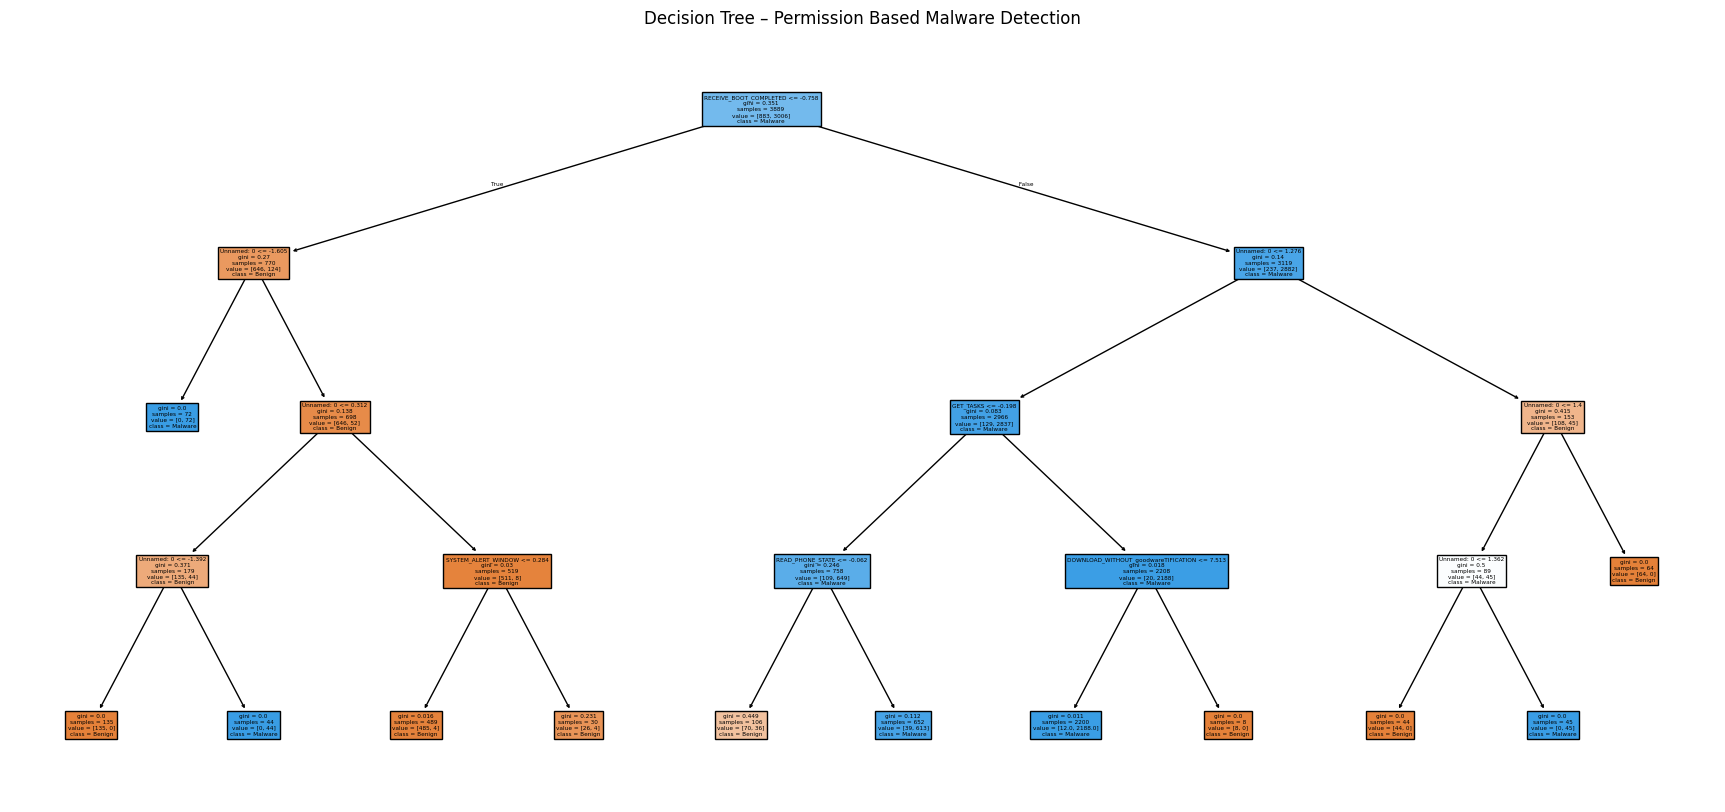

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=4)
dt.fit(X_train, y_train)

plt.figure(figsize=(22,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Benign","Malware"],
    filled=True
)
plt.title("Decision Tree – Permission Based Malware Detection")
plt.show()


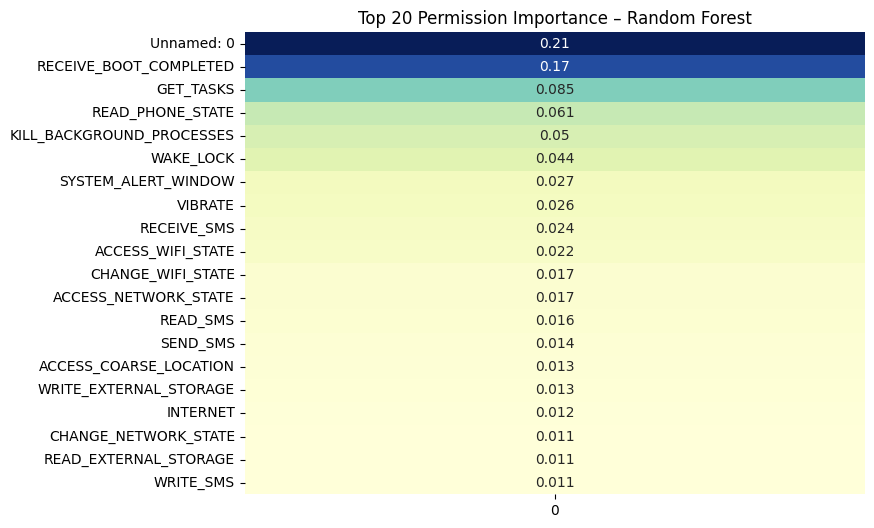

In [ ]:
import numpy as np

top_features = sorted(
    zip(X.columns, rf.feature_importances_),
    key=lambda x: x[1],
    reverse=True
)[:20]

labels, scores = zip(*top_features)

plt.figure(figsize=(8,6))
sns.heatmap(
    np.array(scores).reshape(-1,1),
    annot=True,
    yticklabels=labels,
    cmap="YlGnBu",
    cbar=False
)
plt.title("Top 20 Permission Importance – Random Forest")
plt.show()


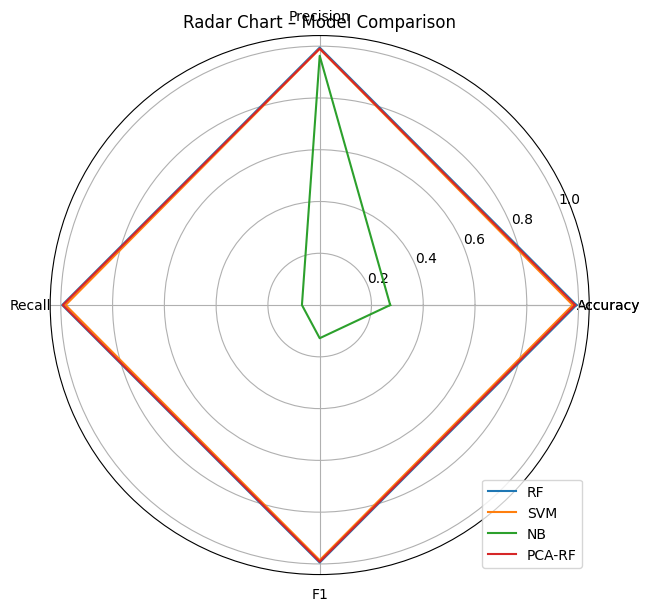

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

metrics = ["Accuracy","Precision","Recall","F1"]

def get_scores(y_true, y_pred):
    return [
        accuracy_score(y_true,y_pred),
        precision_score(y_true,y_pred),
        recall_score(y_true,y_pred),
        f1_score(y_true,y_pred)
    ]

rf_scores = get_scores(y_test, rf_pred)
svm_scores = get_scores(y_test, svm_pred)
nb_scores = get_scores(y_test, nb_pred)
# Use rf_pca_pred for the PCA-RF model, as 'ensemble_pred' is not defined.
rf_pca_scores = get_scores(y_test, rf_pca_pred)

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.concatenate([angles, [angles[0]]]) # Close the loop for plotting

plt.figure(figsize=(7,7))
for scores, label in zip(
    [rf_scores, svm_scores, nb_scores, rf_pca_scores],
    ["RF","SVM","NB","PCA-RF"]
):
    scores = scores + [scores[0]] # Close the loop for the data
    plt.polar(angles, scores, label=label)

# Extend metrics to match the length of angles for thetagrids
metrics_for_thetagrids = metrics + [metrics[0]]
plt.thetagrids(angles*180/np.pi, metrics_for_thetagrids)
plt.title("Radar Chart – Model Comparison")
plt.legend(loc="lower right")
plt.show()


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('nb', nb)
    ],
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)

print("Stacking Ensemble Performance")
print(classification_report(y_test, stack_pred))


Stacking Ensemble Performance
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       215
         1.0       0.99      1.00      0.99       758

    accuracy                           0.99       973
   macro avg       0.99      0.99      0.99       973
weighted avg       0.99      0.99      0.99       973



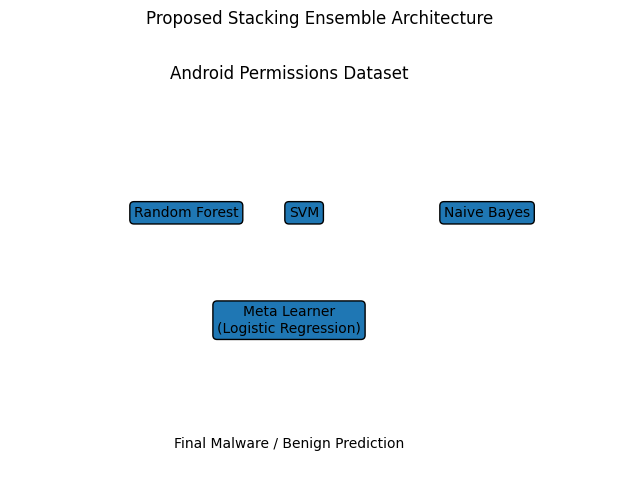

In [ ]:
plt.figure(figsize=(8,6))

plt.text(0.45, 0.9, "Android Permissions Dataset", ha="center", fontsize=12)

plt.text(0.2, 0.6, "Random Forest", bbox=dict(boxstyle="round"))
plt.text(0.45, 0.6, "SVM", bbox=dict(boxstyle="round"))
plt.text(0.7, 0.6, "Naive Bayes", bbox=dict(boxstyle="round"))

plt.text(0.45, 0.35, "Meta Learner\n(Logistic Regression)",
         bbox=dict(boxstyle="round"), ha="center")

plt.text(0.45, 0.1, "Final Malware / Benign Prediction", ha="center")

plt.axis("off")
plt.title("Proposed Stacking Ensemble Architecture")
plt.show()


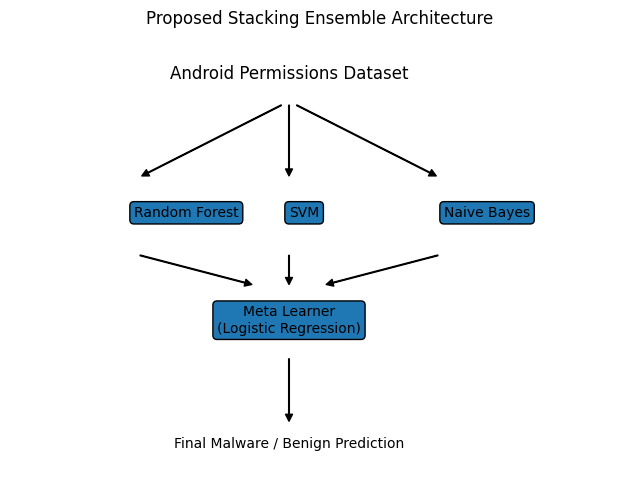

In [ ]:
plt.figure(figsize=(8,6))

plt.text(0.45, 0.9, "Android Permissions Dataset", ha="center", fontsize=12)

plt.text(0.2, 0.6, "Random Forest", bbox=dict(boxstyle="round"))
plt.text(0.45, 0.6, "SVM", bbox=dict(boxstyle="round"))
plt.text(0.7, 0.6, "Naive Bayes", bbox=dict(boxstyle="round"))

plt.text(0.45, 0.35, "Meta Learner\n(Logistic Regression)",
         bbox=dict(boxstyle="round"), ha="center")

plt.text(0.45, 0.1, "Final Malware / Benign Prediction", ha="center")

# Add arrows to connect the components
arrow_props = dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5, headlength=5)

# Dataset to Base Learners
plt.annotate('', xy=(0.2, 0.68), xytext=(0.45, 0.85), arrowprops=arrow_props)
plt.annotate('', xy=(0.45, 0.68), xytext=(0.45, 0.85), arrowprops=arrow_props)
plt.annotate('', xy=(0.7, 0.68), xytext=(0.45, 0.85), arrowprops=arrow_props)

# Base Learners to Meta Learner
plt.annotate('', xy=(0.4, 0.45), xytext=(0.2, 0.52), arrowprops=arrow_props)
plt.annotate('', xy=(0.45, 0.45), xytext=(0.45, 0.52), arrowprops=arrow_props)
plt.annotate('', xy=(0.5, 0.45), xytext=(0.7, 0.52), arrowprops=arrow_props)

# Meta Learner to Final Prediction
plt.annotate('', xy=(0.45, 0.15), xytext=(0.45, 0.3), arrowprops=arrow_props)

plt.axis("off")
plt.title("Proposed Stacking Ensemble Architecture")
plt.show()


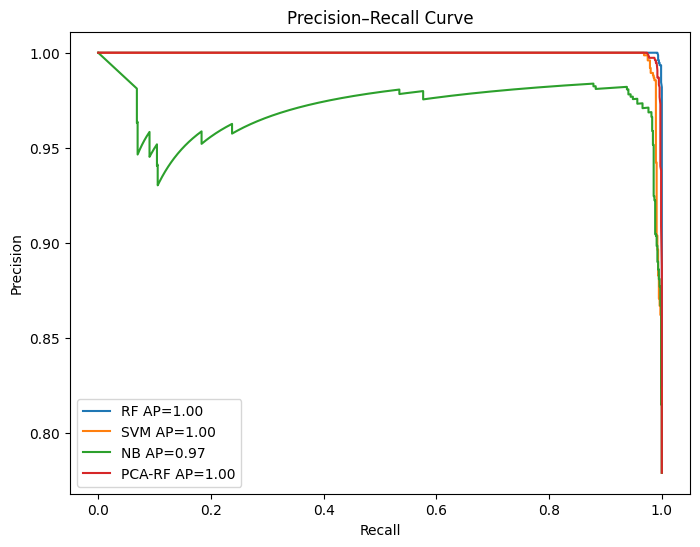

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))

# Prepare list of models and their predictions for PR curve plotting
# Note: rf_pca was trained on X_train_pca, so it should predict on X_test_pca
models_for_pr_curve = {
    "RF": rf,
    "SVM": svm,
    "NB": nb,
    "PCA-RF": rf_pca
}

for name, model in models_for_pr_curve.items():
    if name == "PCA-RF":
        probs = model.predict_proba(X_test_pca)[:,1]
    else:
        probs = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f"{name} AP={ap:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()
